# K-Means Clustering

This notebook is used for generating the extrapolative splits by K-Means clustering algorithm.

In [1]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns

rc = mpl.rc_params_from_file("/home/akshatz/.config/matplotlib/matplotlibrc", use_default_template=False)
sns.set_theme(style="white", rc=rc)
mpl.rcParams.update(rc)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Union
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from rdmc.mol import  RDKitMol
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
print(rdkit.__version__)

my_blue = "#83CDE6"
my_red = "#A4394A"
my_yellow = "#EECD62"
my_green = "#62B46A"
my_navy = "#1E4167"
my_grey = "#5A5A5A"

def get_fingerprint(smi):
    return GetMorganGenerator(fpSize=2048, radius=4).GetCountFingerprintAsNumPy(RDKitMol.FromSmiles(smi))

2023.09.3


[12:25:49] WARNING: not removing hydrogen atom without neighbors


In [3]:
all_data_set = pd.read_csv("../../rigr_h298_50k/dataset/all_data_set.csv")
all_aug_data_set = pd.read_csv("../../rigr_h298_50k/dataset/all_aug_data_set.csv")

In [4]:
X = np.vstack(all_data_set['resonance_smis'].apply(
    lambda x: get_fingerprint(x)).values)
#df_morgan = pd.DataFrame(X)
#df_morgan['resonance_smis'] = cleaned_data_set['resonance_smis'].values
df_morgan = pd.DataFrame(X, index=all_data_set.index).astype(int)
df_morgan.head(10)

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print(f"The largest number of counts encountered:\n{df_morgan.max().max()}")
nonzero_bits = df_morgan.loc[:, (df_morgan != 0).any(axis=0)].columns
print(f"The number of non-zero bits:\n{len(nonzero_bits)}")

The largest number of counts encountered:
26
The number of non-zero bits:
2048


In [6]:
def fit_pca(
    fingerprints: np.ndarray,
    n_components: int = 4,
    random_state: int = 20,
    standardize: bool = False,
) -> np.ndarray:

    steps = [('standardize', StandardScaler())] if standardize else []
    steps.append(('pca', PCA(n_components=n_components,
                             random_state=random_state)))
    model = Pipeline(steps=steps)
    return model.fit_transform(fingerprints), model


def fit_kmeans(
    fingerprints: Union[pd.DataFrame, np.ndarray],
    pca: bool = True,
    n_components: int = 4,
    n_clusters: int = 12,
    n_init: int = 50,
    random_state: int = 20,
    standardize: bool = False,
) -> np.ndarray:

    if isinstance(fingerprints, pd.DataFrame):
        fingerprints = fingerprints.values
    if pca:
        fingerprints, pca = fit_pca(
            fingerprints,
            n_components=n_components,
            random_state=random_state,
            standardize=standardize,
    )
    else:
        pca = None
    kmeans = KMeans(n_clusters=n_clusters,
                    n_init=n_init,
                    random_state=random_state,
                    ).fit(fingerprints)
    return kmeans.labels_, pca, kmeans

In [7]:
n_components = 0.8
random_state = 20

X_trans, pca = fit_pca(
    fingerprints=X,
    n_components=n_components,
    random_state=random_state,
    standardize=False
)

372


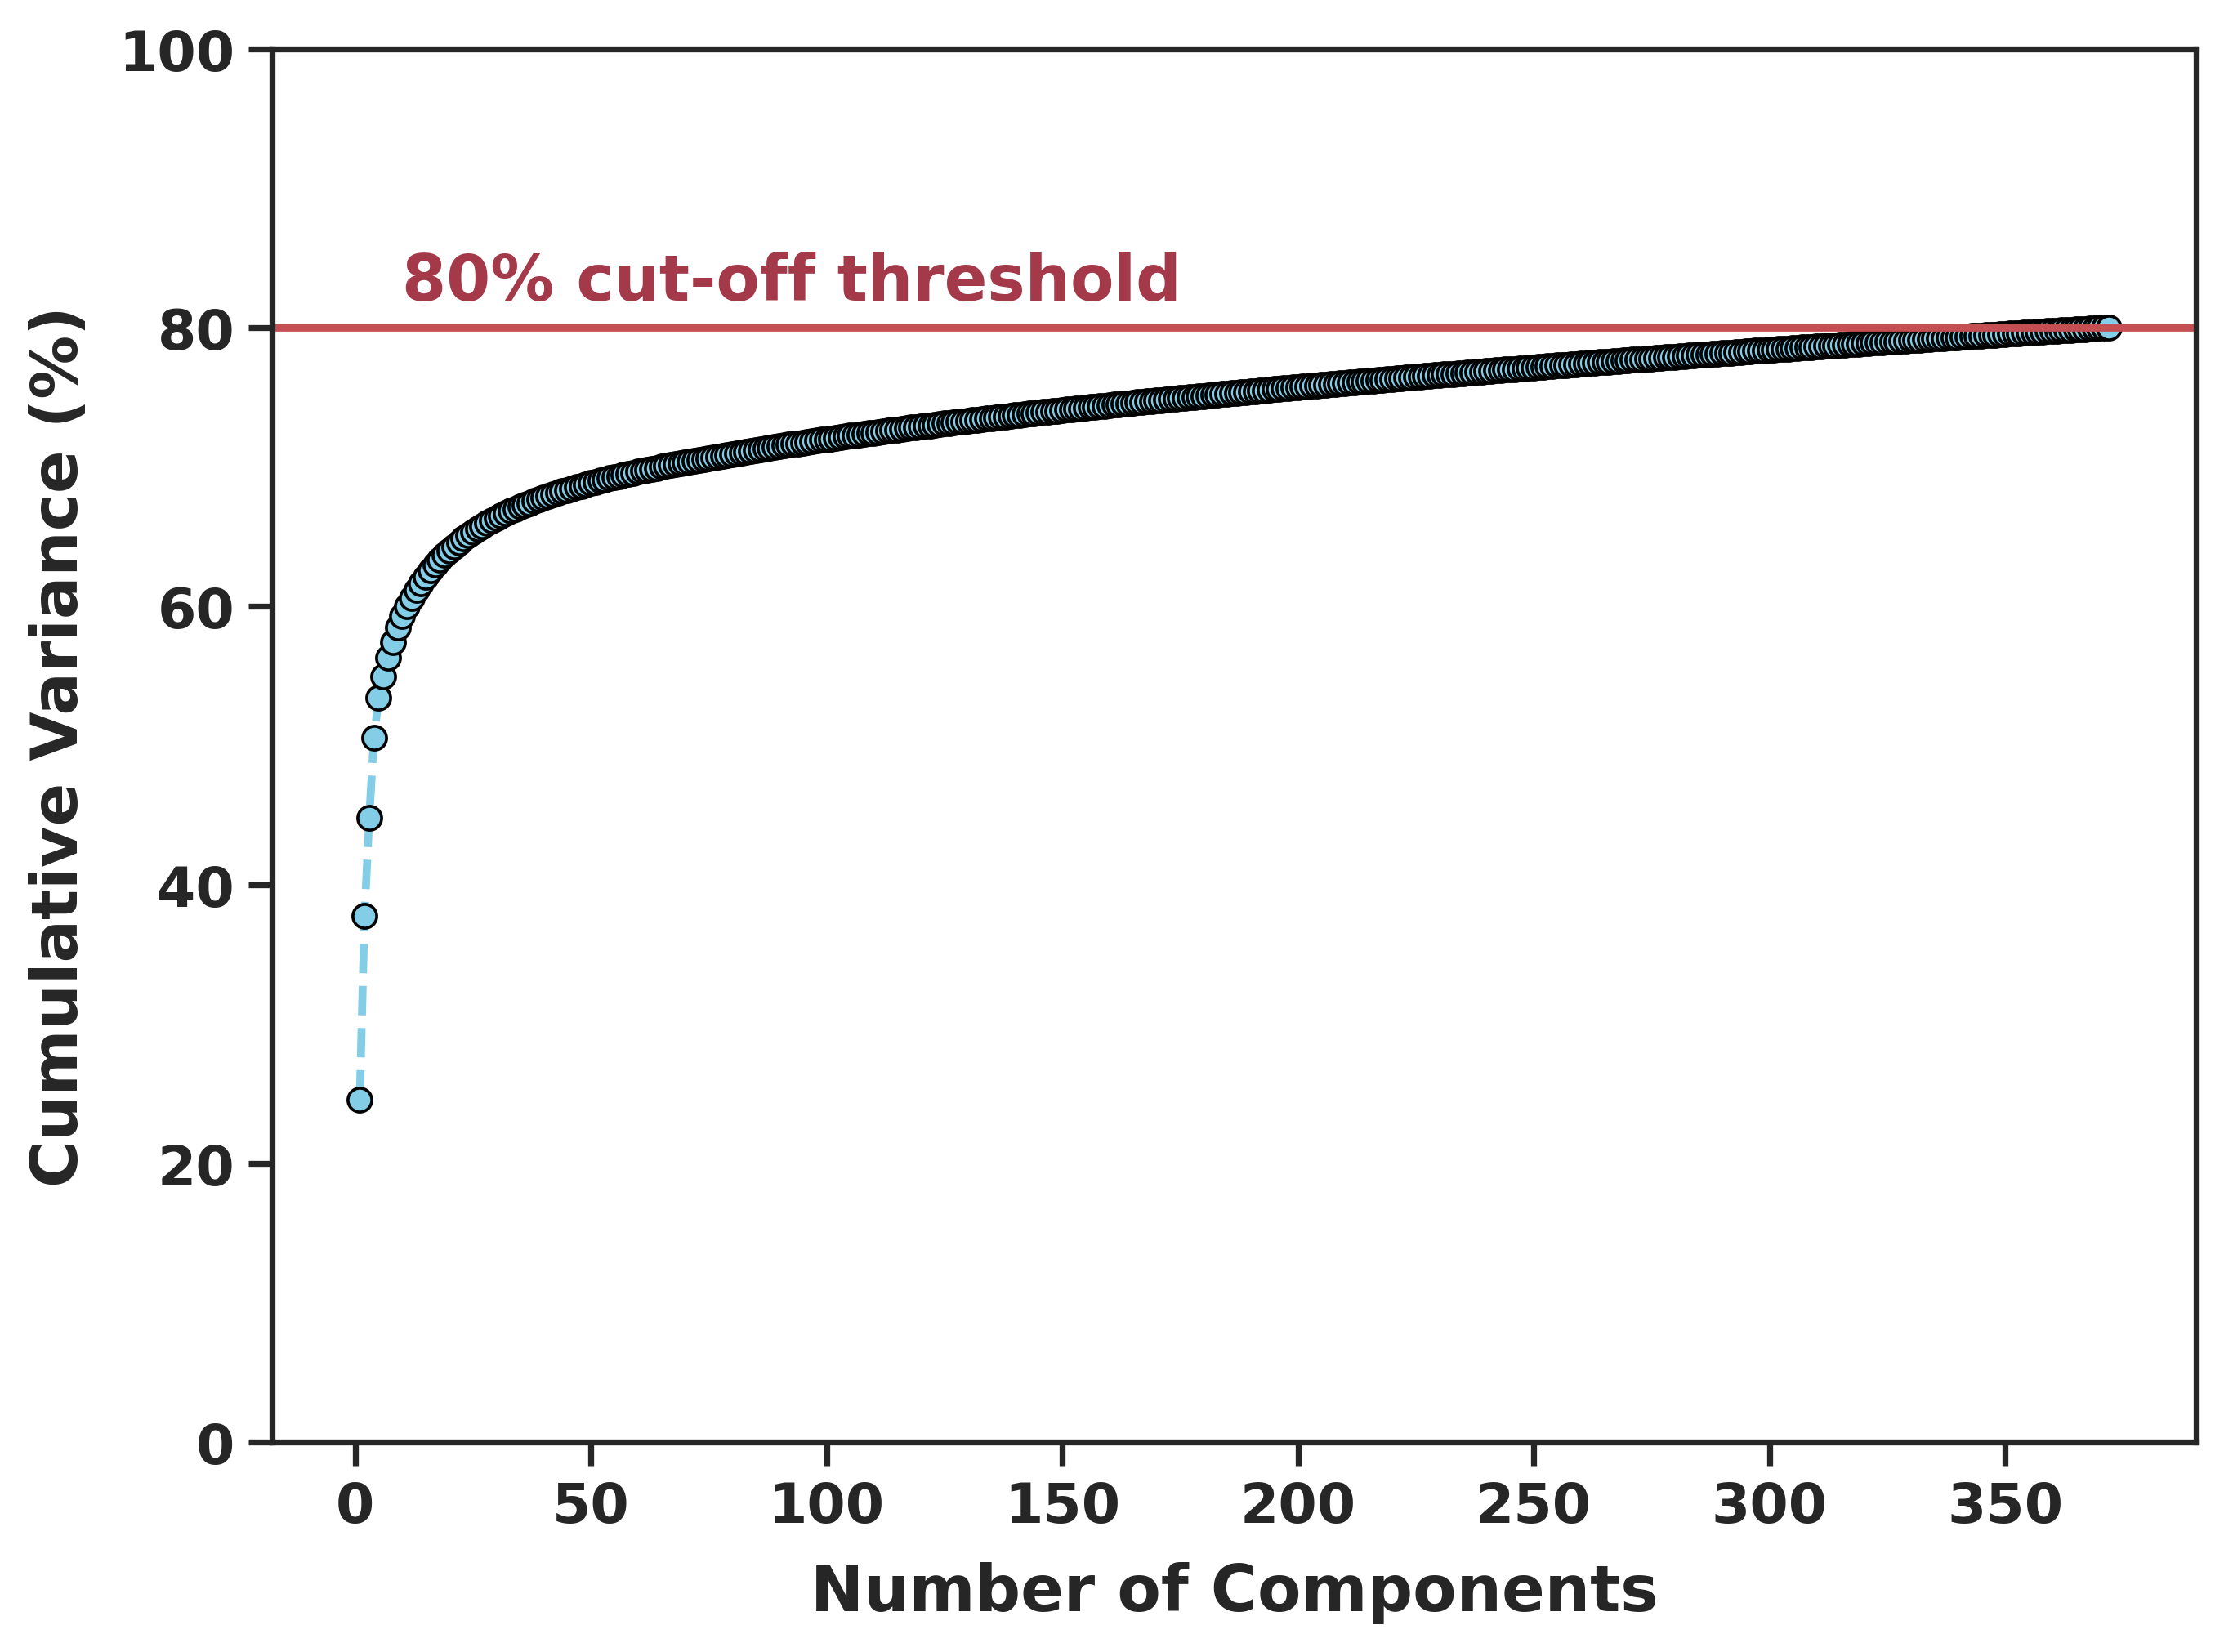

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=350)

n_components = len(pca['pca'].explained_variance_ratio_)
print(n_components)
xi = np.arange(1, n_components+1, step=1)
y = np.cumsum(pca['pca'].explained_variance_ratio_) * 100
ax = sns.lineplot(x=xi,
                  y=y,
                  marker='o',
                  markeredgecolor='black',
                  linestyle='--',
                  color=my_blue,
                 )
ax.set_xlabel('Number of Components', labelpad=7)
# ax.set_xticks(np.arange(1, n_components+1, step=2)) # change from 0-based array index to 1-based human-readable label

# ax.set_ylim(0.0, 1)
ax.set_yticks(np.arange(0, 1.1*100, 0.2*100)) # change from 0-based array index to 1-based human-readable label

ax.set_ylabel('Cumulative Variance (%)', labelpad=7)
# plt.title('Number of components needed to explain variance')

ax.axhline(y=80, color='r', linestyle='-')
ax.text(10, 0.82*100, '80% cut-off threshold', color = my_red, fontsize=16)
fig.tight_layout()

fig.savefig("/home/akshatz/bond_order_free/figures_si/pca_explained.pdf", bbox_inches="tight")

In [9]:
n_components = 372
random_state = 20

components, pca = fit_pca(
    fingerprints=X,
    n_components=n_components,
    random_state=random_state,
    standardize=False
)

In [10]:
components = pca.transform(df_morgan.values)

In [11]:
N = 35
distortions = []
inertias = []
silhouette_scores = []

Ks = np.arange(2, N)
for K in Ks:
    kmeanModel = KMeans(n_clusters=K, n_init=50, random_state=20).fit(components)
    
    silhouette_scores.append(silhouette_score(components, kmeanModel.labels_))
    distortions.append(sum(np.min(cdist(components, kmeanModel.cluster_centers_,
                                        'euclidean'), axis=1)) / components.shape[0])
    inertias.append(kmeanModel.inertia_)

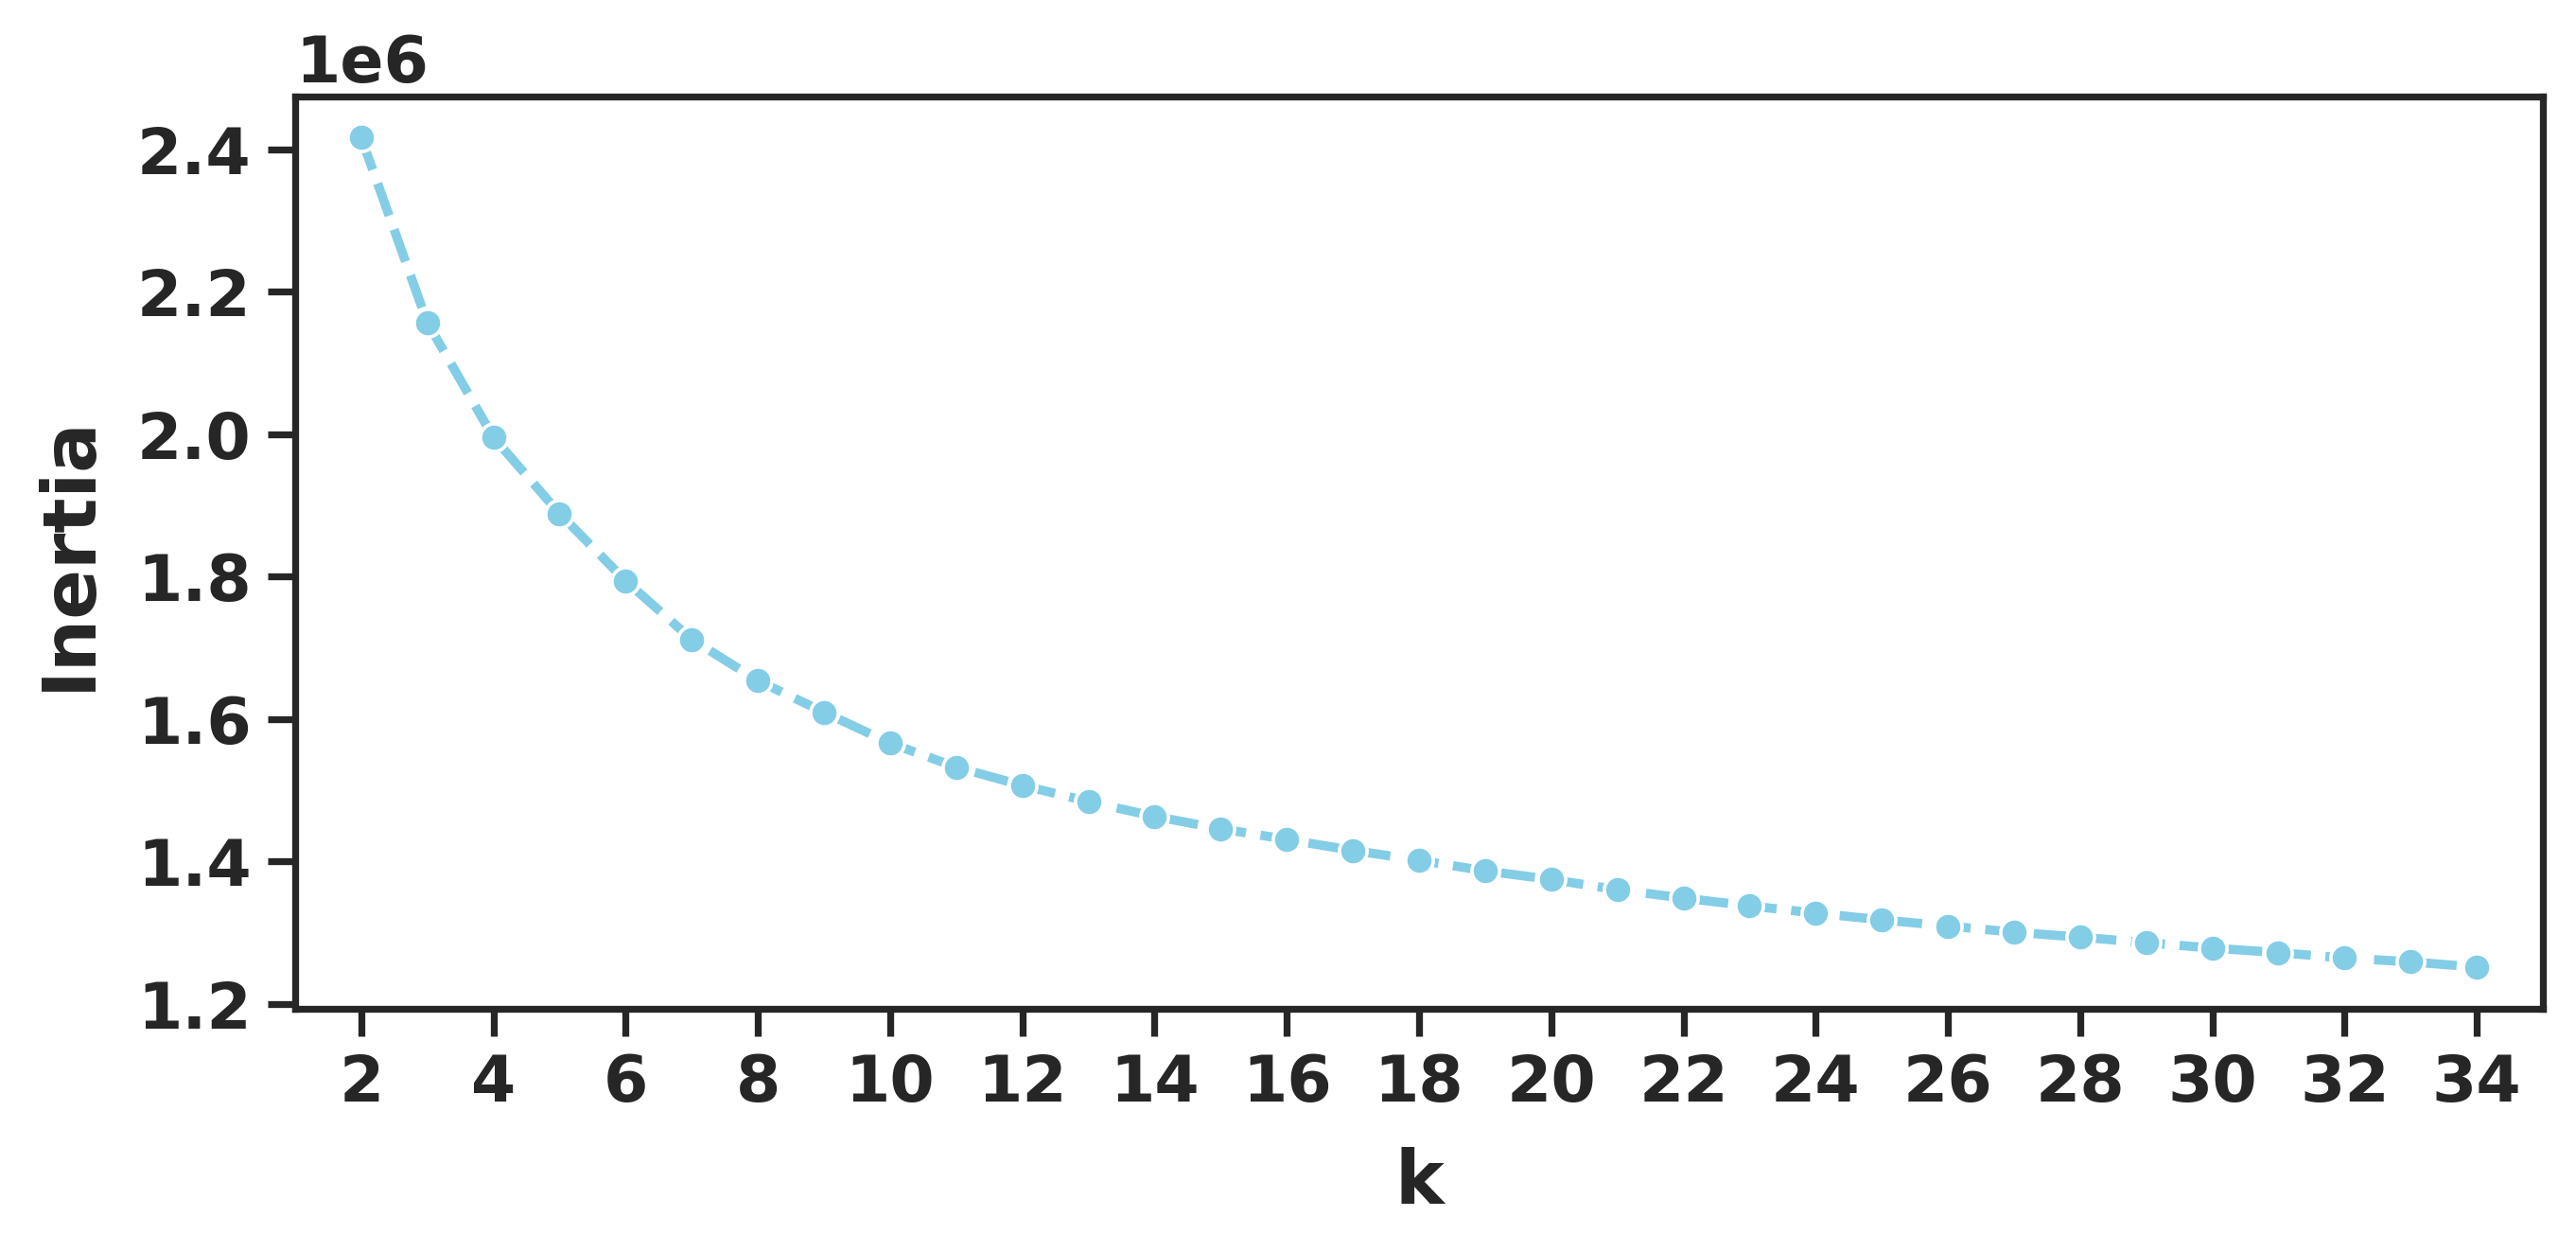

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=350)

ax = sns.lineplot(x=Ks,
                  y=inertias,
                  marker='o',
                  linestyle='--',
                  color=my_blue,
                 )

ax.set_xlim([1, N])
ax.set_xlabel('k', labelpad=7)
ax.set_xticks(np.arange(2, N, 2))

# ax.set_ylim(0.0, 1)
# ax.set_yticks(np.arange(0, 30_000, 5_000))

ax.set_ylabel('Inertia', labelpad=7)
# plt.title('Number of components needed to explain variance')

fig.tight_layout()
fig.savefig("/home/akshatz/bond_order_free/figures_si/inertia.pdf", bbox_inches="tight")

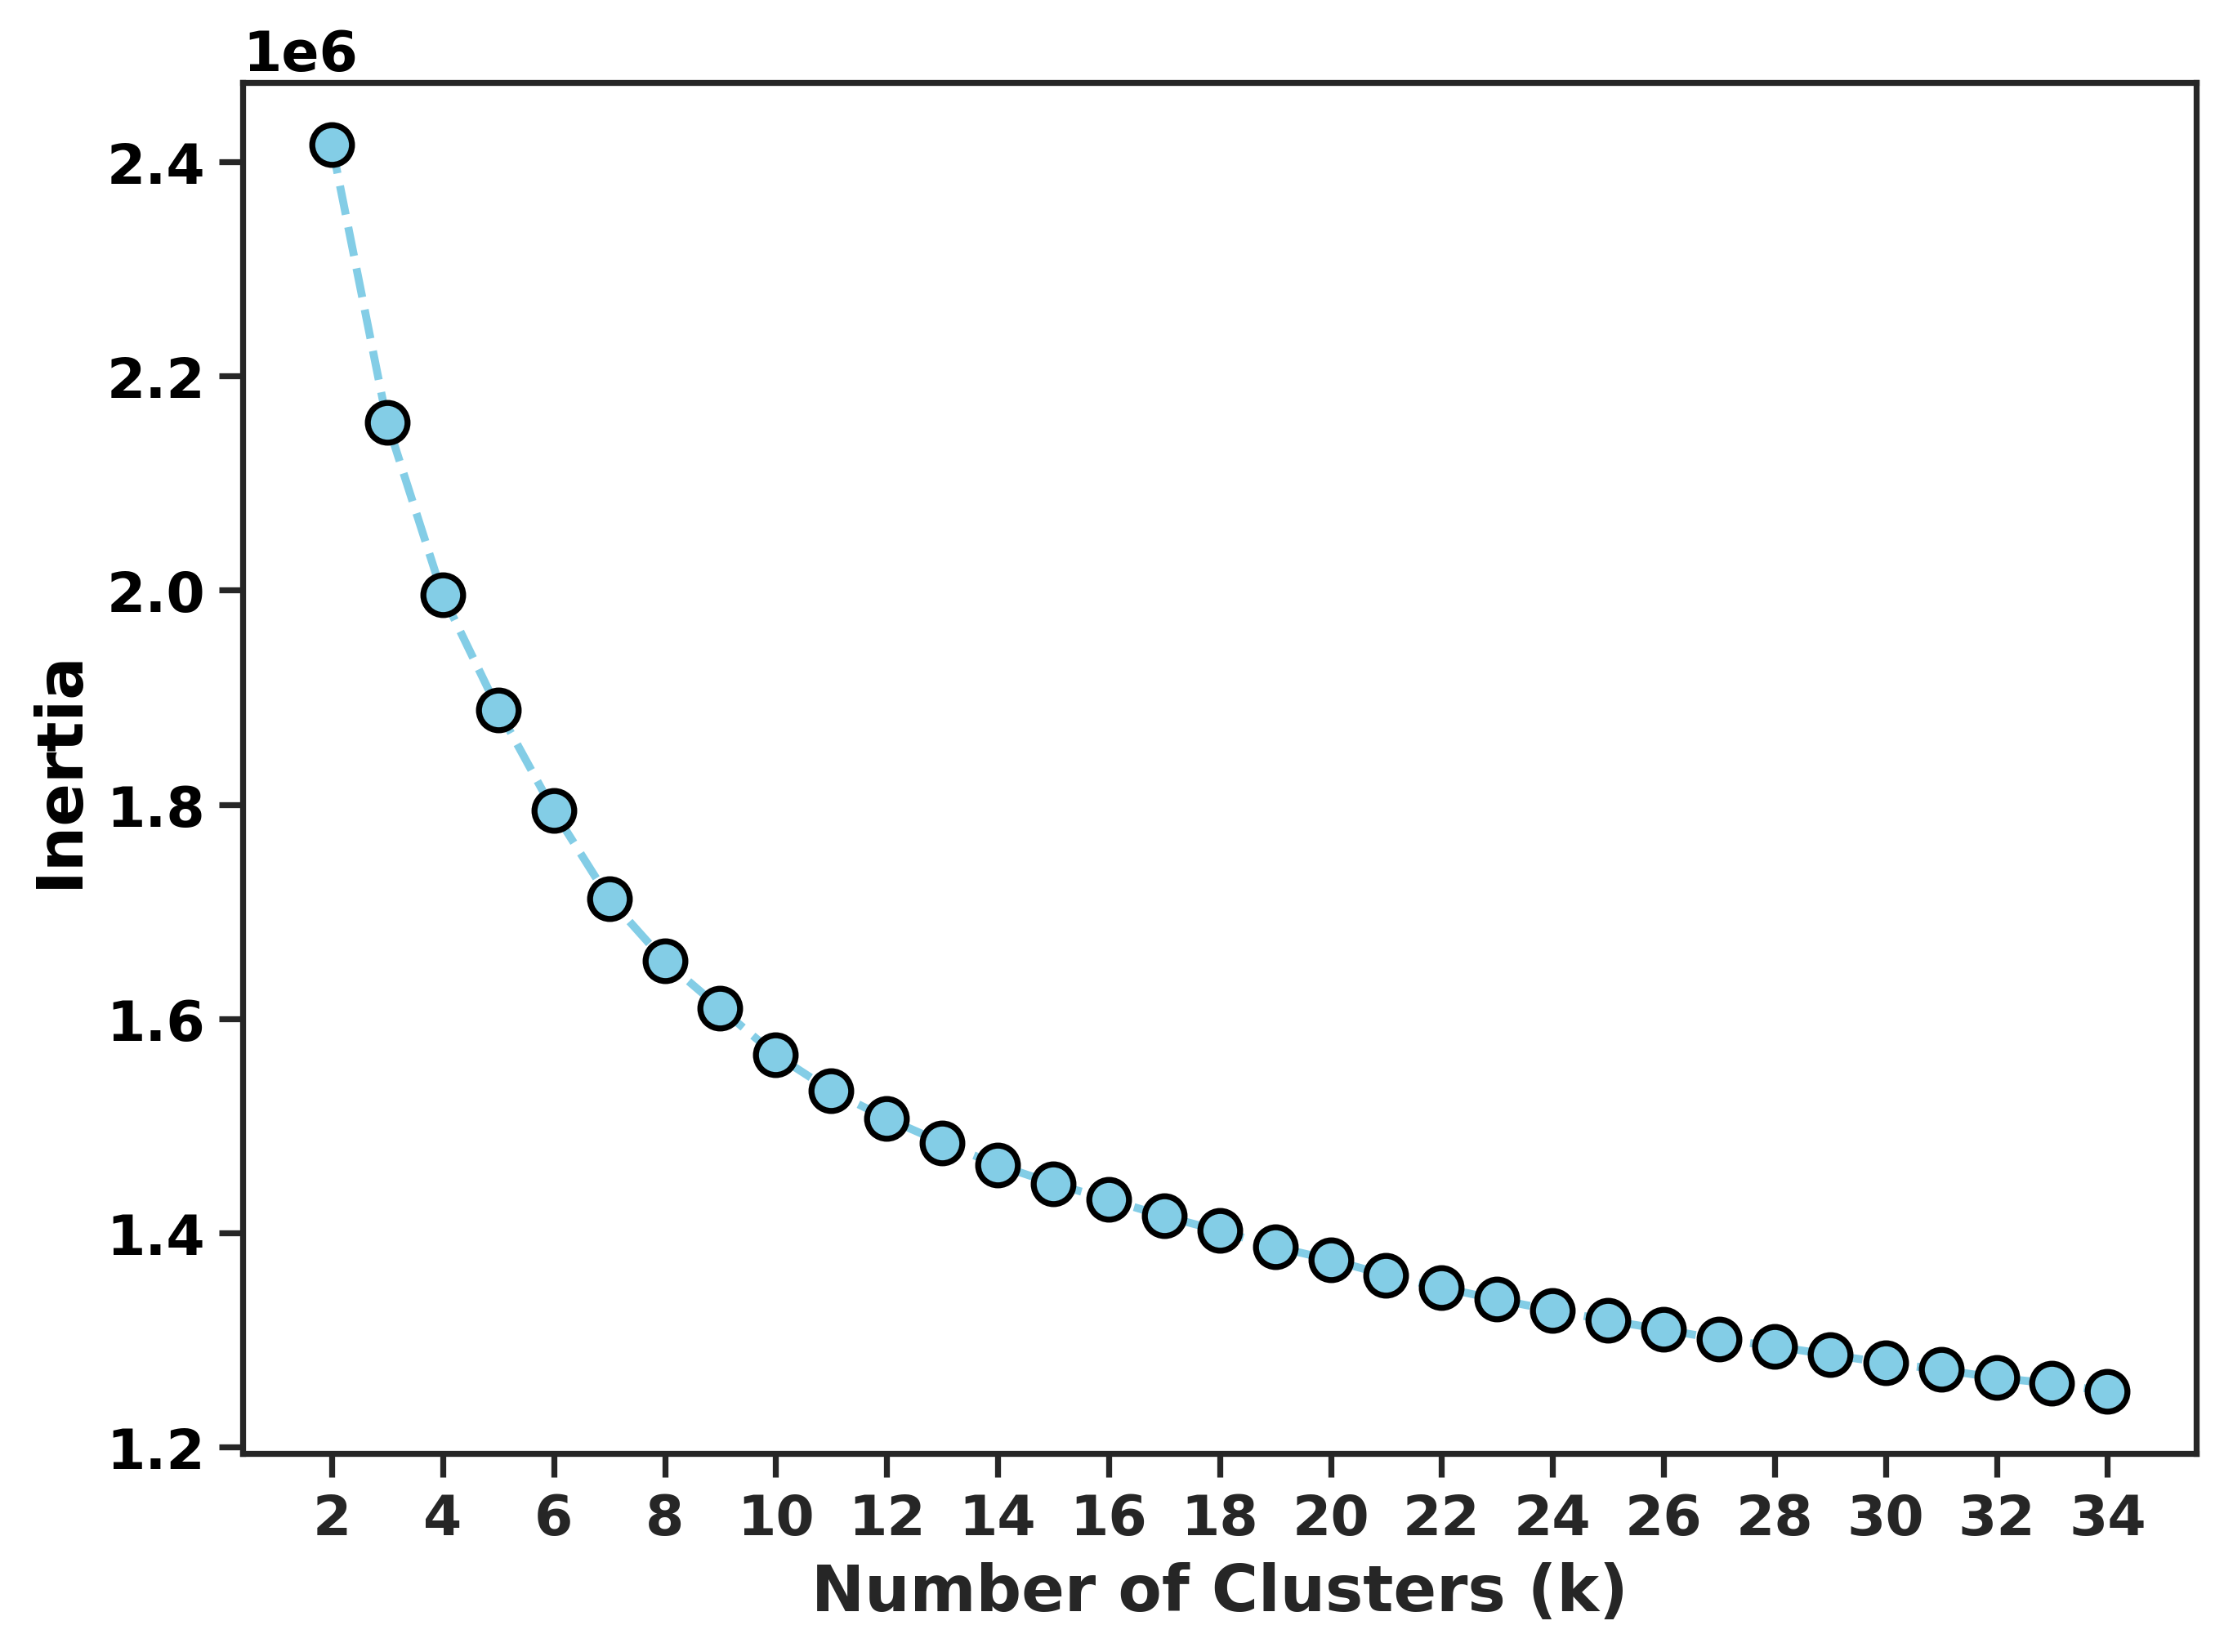

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=350)
# ax2 = ax.twinx()
ax.plot(Ks, inertias, '--o', color=my_blue, markersize=10, markeredgecolor='black', markeredgewidth = 1.5)
ax.set_xticks(Ks);
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia', color='black')
ax.tick_params(axis="y", labelcolor='black')
ax.set_xticks(np.arange(2, N, 2))
# ax2.plot(Ks, silhouette_scores, '--o', color=my_red, markersize=10, markeredgecolor='black', markeredgewidth = 1.5)
# ax2.set_xticks(np.arange(2, N, 2));
# ax2.set_xlabel('k')
# ax2.set_ylabel('Silhouette Score', color=my_red)
# ax2.tick_params(axis="y", labelcolor=my_red)

fig.tight_layout()
fig.savefig("/home/akshatz/bond_order_free/figures_si/inertia.pdf", bbox_inches="tight")


In [25]:
# n_components = 15
n_components = 0.8  # choose number of components dynamically
n_clusters = 18  # hyperparameter
random_state = 20

cluster_assign, pca, kmean_model = fit_kmeans(
    df_morgan,
    pca=True,
    n_components=n_components,
    n_clusters=n_clusters,
    random_state=random_state,
    standardize=False,
)

In [26]:
print(
    f"{len(pca['pca'].explained_variance_ratio_)} PCs. "
    f"Explained variance ratio of each PC:\n"
    f"{pca['pca'].explained_variance_ratio_}"
    f" covering {sum(pca['pca'].explained_variance_ratio_):.1%}"
)

372 PCs. Explained variance ratio of each PC:
[2.45800414e-01 1.31988167e-01 6.99868519e-02 5.75738057e-02
 2.88056568e-02 1.55876719e-02 1.33063447e-02 1.13118814e-02
 1.01170593e-02 8.52721885e-03 7.00584676e-03 6.02664038e-03
 5.40580886e-03 4.98515149e-03 4.80770378e-03 4.72706442e-03
 4.06121991e-03 3.62805134e-03 3.39481646e-03 2.98061625e-03
 2.97299423e-03 2.86518055e-03 2.69941555e-03 2.48496789e-03
 2.29127263e-03 2.26591414e-03 2.05861567e-03 2.02325364e-03
 1.94845943e-03 1.86842138e-03 1.70859782e-03 1.57284041e-03
 1.55169363e-03 1.48308849e-03 1.48027727e-03 1.43998601e-03
 1.38495862e-03 1.34065716e-03 1.28395283e-03 1.19236249e-03
 1.14636830e-03 1.12653747e-03 1.08199884e-03 1.07526461e-03
 1.05944119e-03 1.02680959e-03 1.00985742e-03 9.68636559e-04
 9.55349725e-04 9.29287091e-04 8.93969364e-04 8.66138825e-04
 8.54053462e-04 8.44044280e-04 8.19975726e-04 7.95309817e-04
 7.82171411e-04 7.76621852e-04 7.71435119e-04 7.57408456e-04
 7.25832840e-04 7.18715515e-04 7.064094

In [27]:
from matplotlib.colors import LinearSegmentedColormap

In [28]:
colors = ['#EB6662', '#F7B172', '#F7D37E', '#82C881', '#1D8F94', '#203D85']
colors = [my_blue, my_red, my_yellow, my_grey, my_navy]
cmap = LinearSegmentedColormap.from_list('my_colormap', colors, N=n_clusters)
colors = [cmap(i) for i in range(n_clusters)]
pal = sns.color_palette(colors)
display(pal)

[(0.5137254901960784, 0.803921568627451, 0.9019607843137255),
 (0.5441753171856978, 0.6673587081891581, 0.7580161476355248),
 (0.5746251441753172, 0.5307958477508651, 0.614071510957324),
 (0.6050749711649366, 0.3942329873125721, 0.4701268742791234),
 (0.635524798154556, 0.25767012687427915, 0.3261822376009227),
 (0.6943483275663207, 0.3259515570934256, 0.30680507497116494),
 (0.7626297577854672, 0.4625144175317185, 0.3289504036908881),
 (0.8309111880046136, 0.5990772779700116, 0.3510957324106113),
 (0.8991926182237602, 0.7356401384083046, 0.3732410611303345),
 (0.8650519031141869, 0.7508650519031143, 0.3806228373702422),
 (0.7284890426758939, 0.6447520184544406, 0.3732410611303345),
 (0.591926182237601, 0.538638985005767, 0.3658592848904268),
 (0.4553633217993082, 0.4325259515570936, 0.3584775086505191),
 (0.3391003460207613, 0.34717416378316035, 0.3559400230680508),
 (0.2837370242214533, 0.32410611303344866, 0.3679354094579008),
 (0.22837370242214533, 0.30103806228373703, 0.37993079584775086),
 (0.17301038062283738, 0.27797001153402534, 0.39192618223760095),
 (0.11764705882352941, 0.2549019607843137, 0.403921568627451)]

[Text(0.5, 0, 'Principal Component 1'), Text(0, 0.5, 'Principal Component 2')]

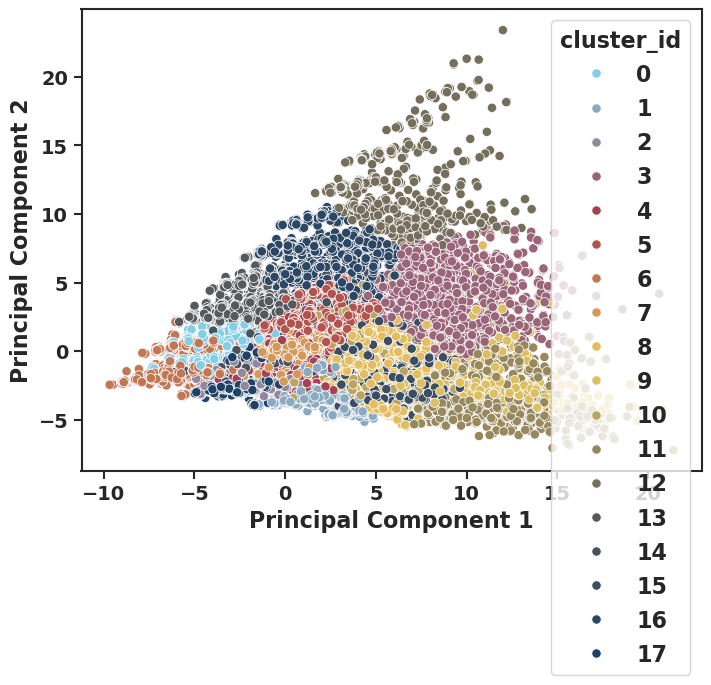

In [29]:
fig, ax = plt.subplots(figsize=(8,6))

components = pca['pca'].transform(df_morgan.values)
df_components = pd.DataFrame(components)
df_components['cluster_id'] = cluster_assign

sns.scatterplot(data=df_components, x=0, y=1, hue='cluster_id', palette=pal, s=45, ax=ax)
#plt.plot(special_components[0][0], special_components[0][1], 'X')
ax.set(xlabel='Principal Component 1', ylabel='Principal Component 2')

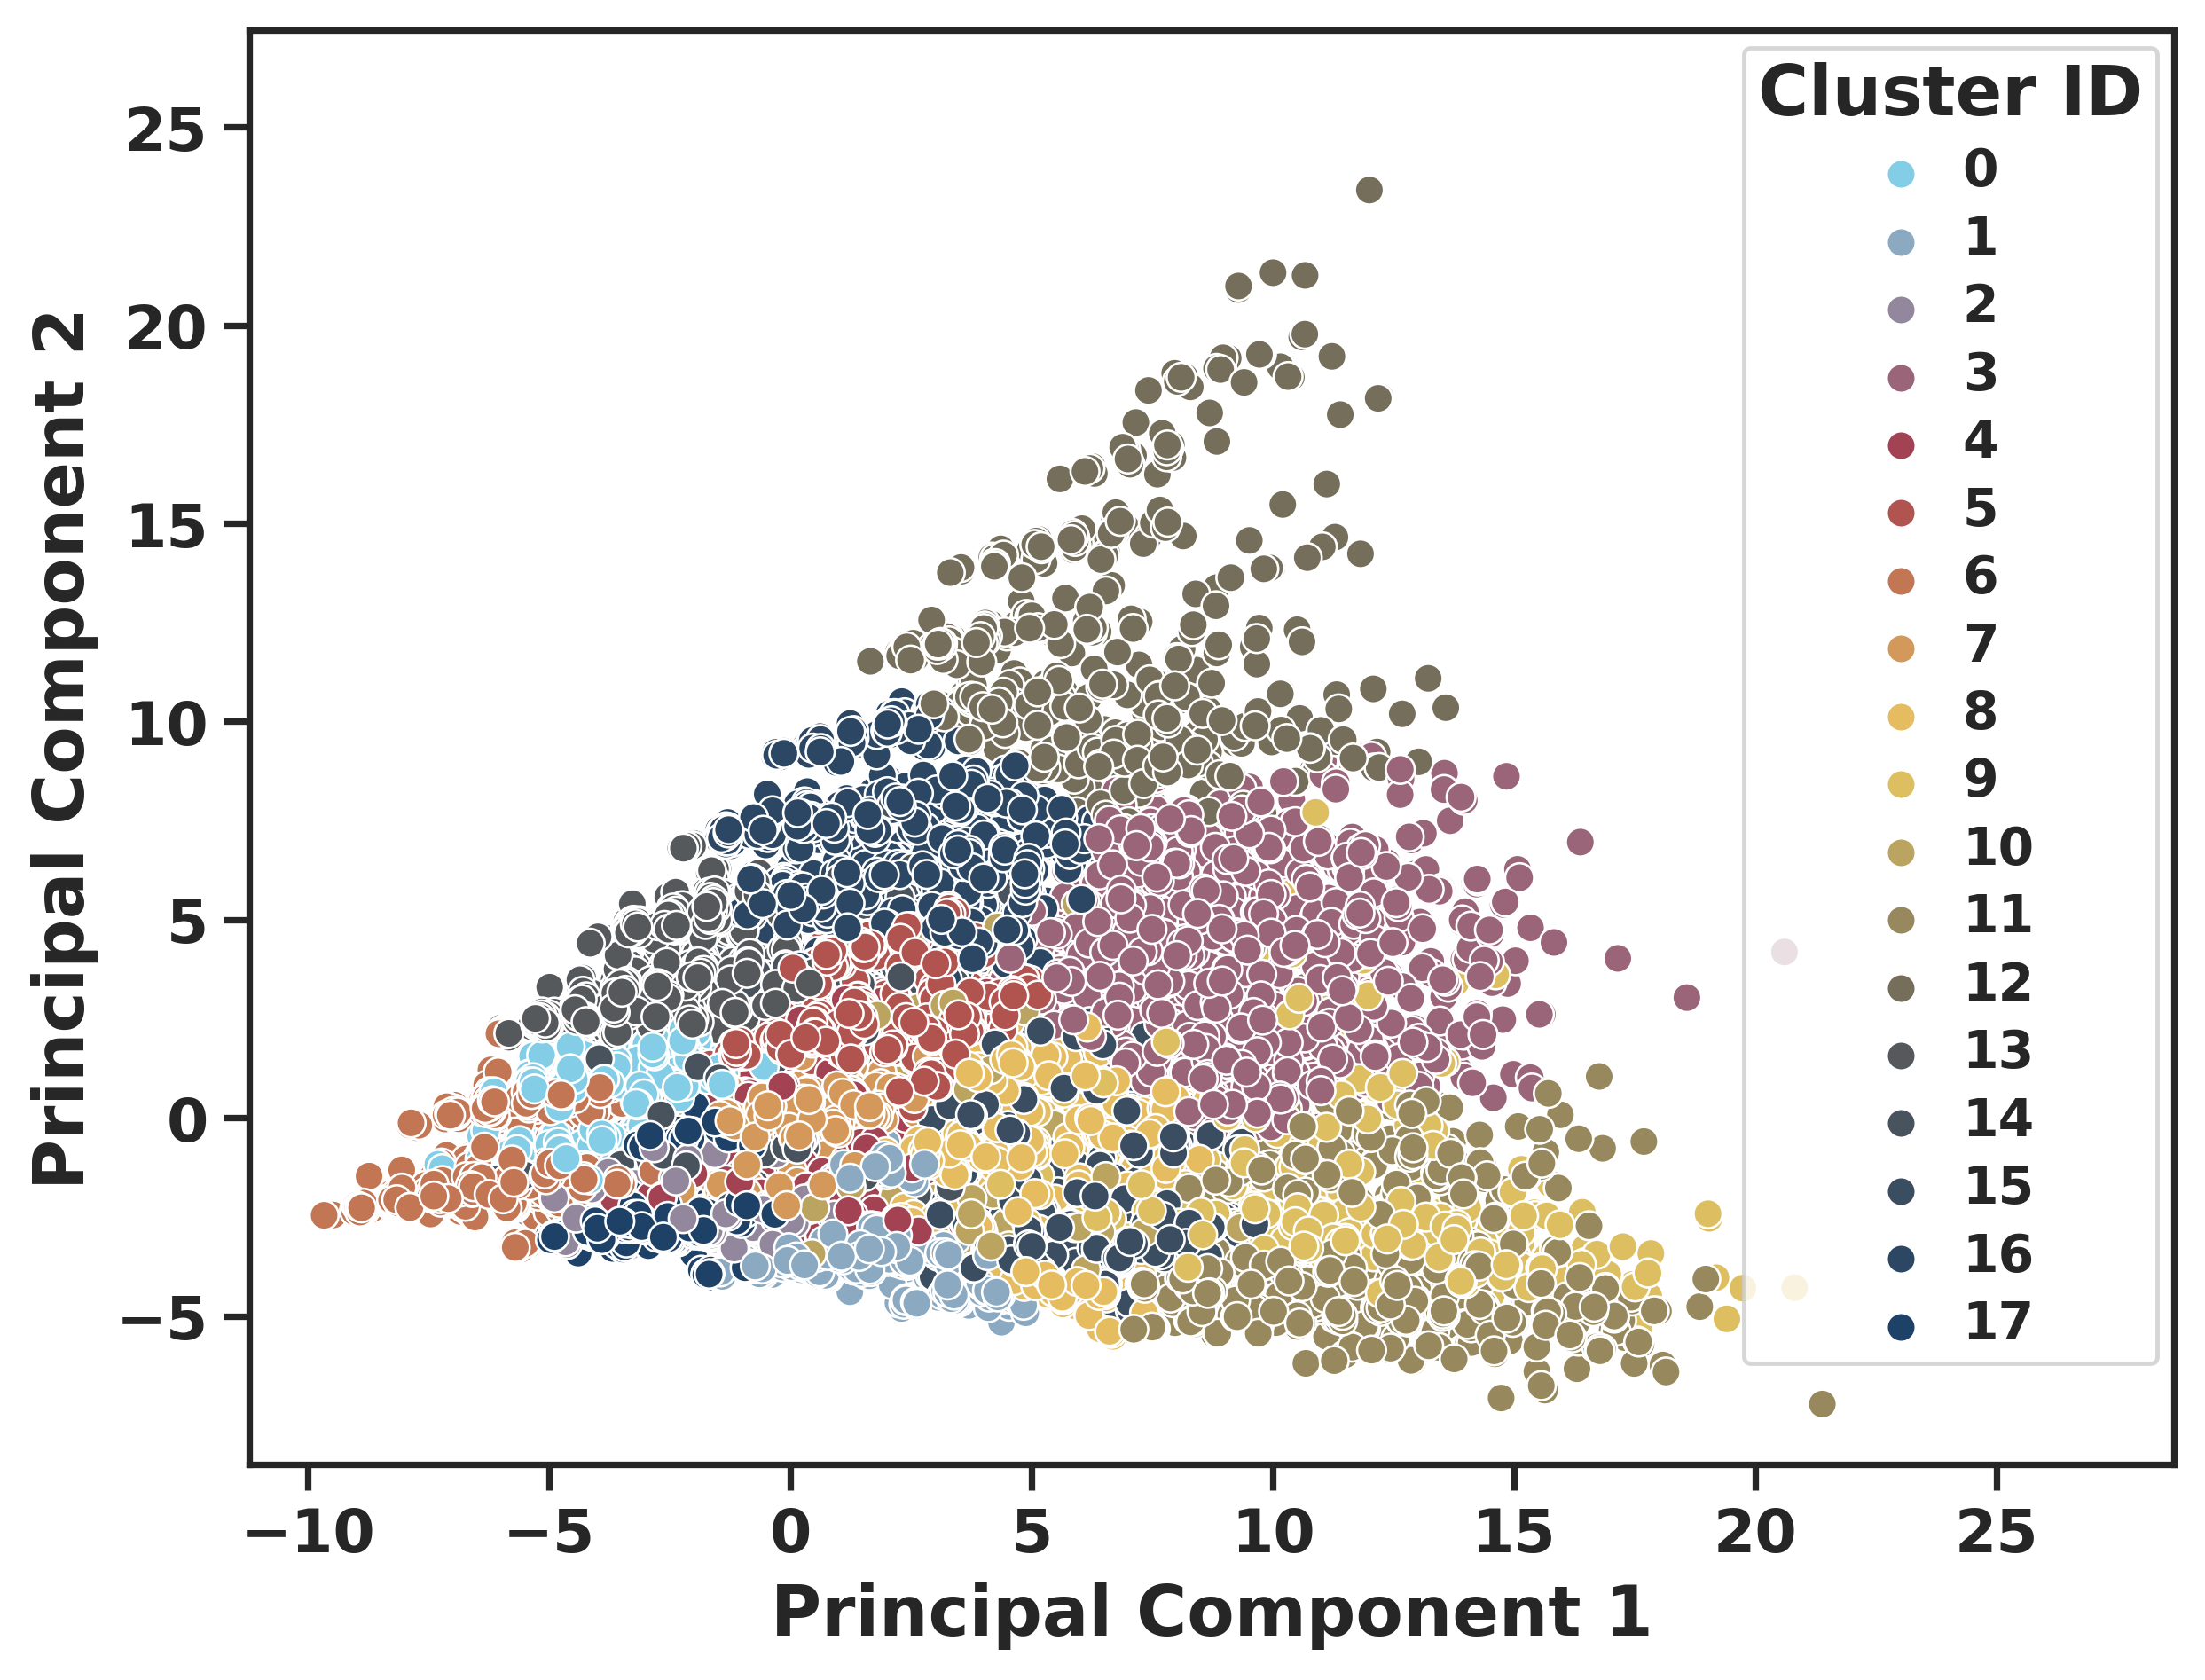

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df_morgan, pca, cluster_assign, and pal are already defined

fig, ax = plt.subplots(figsize=(8,6), dpi=350)

components = pca['pca'].transform(df_morgan.values)
df_components = pd.DataFrame(components)
df_components['cluster_id'] = cluster_assign

sns.scatterplot(data=df_components, x=0, y=1, hue='cluster_id', palette=pal, s=45, ax=ax)

ax.set(xlabel='Principal Component 1', ylabel='Principal Component 2')

xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.set_xlim([xlim[0], xlim[1] * 1.25])  # Increase x-axis by 10%
ax.set_ylim([ylim[0], ylim[1] * 1.1])  # Increase y-axis by 10%
# Customize the legend
legend = ax.legend(title="Cluster ID", frameon=True, fontsize=8)  # Adjust title and font size
# Adjust legend ticks
for label in legend.get_texts():
    label.set_fontsize(12)  # You can change the font size here

fig.show()
fig.savefig("/home/akshatz/bond_order_free/figures_si/all_clusters.pdf", bbox_inches="tight")


/tmp/ipykernel_2702836/2189429546.py:8: UserWarning: The palette list has more values (18) than needed (3), which may not be intended.
  sns.scatterplot(data=df_components_test, x=0, y=1, hue='cluster_id', palette=pal, s=45, ax=ax)


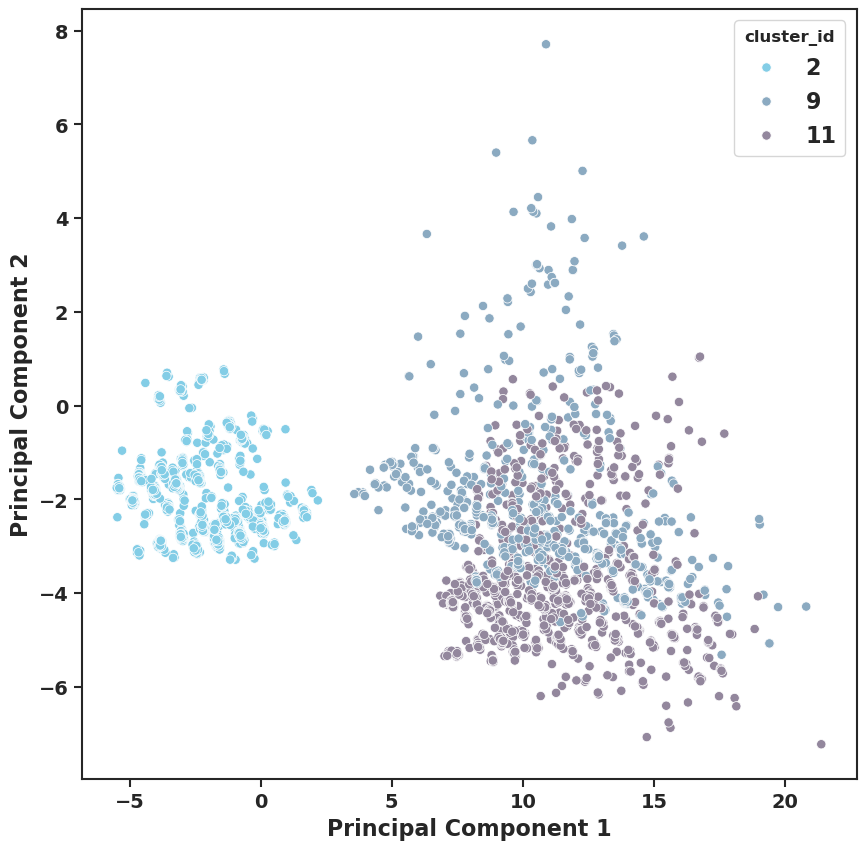

In [19]:
fig, ax = plt.subplots(figsize=(10,10))

components = pca['pca'].transform(df_morgan.values)
df_components = pd.DataFrame(components)
df_components['cluster_id'] = cluster_assign

df_components_test = df_components.query("(cluster_id == 2) or (cluster_id == 11) or (cluster_id == 9)")
sns.scatterplot(data=df_components_test, x=0, y=1, hue='cluster_id', palette=pal, s=45, ax=ax)
#plt.plot(special_components[0][0], special_components[0][1], 'X')
ax.set(xlabel='Principal Component 1', ylabel='Principal Component 2');

/tmp/ipykernel_2702836/3208164610.py:8: UserWarning: The palette list has more values (18) than needed (2), which may not be intended.
  sns.scatterplot(data=df_components_test, x=0, y=1, hue='cluster_id', palette=pal, s=45, ax=ax)


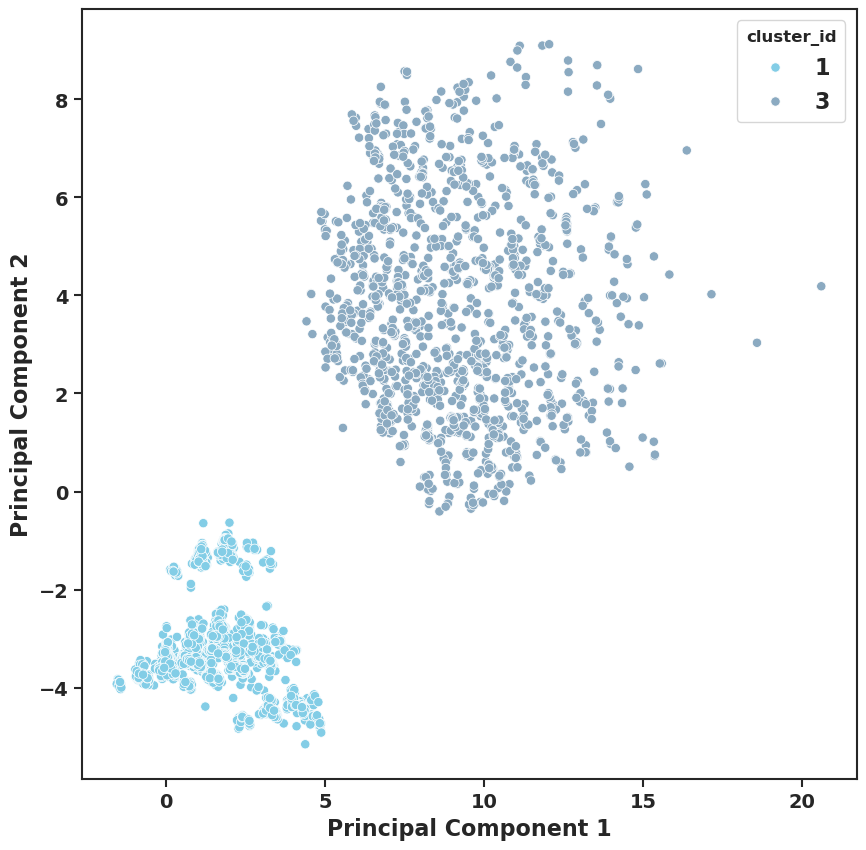

In [20]:
fig, ax = plt.subplots(figsize=(10,10))

components = pca['pca'].transform(df_morgan.values)
df_components = pd.DataFrame(components)
df_components['cluster_id'] = cluster_assign

df_components_test = df_components.query("(cluster_id == 1) or (cluster_id == 3)")
sns.scatterplot(data=df_components_test, x=0, y=1, hue='cluster_id', palette=pal, s=45, ax=ax)
#plt.plot(special_components[0][0], special_components[0][1], 'X')
ax.set(xlabel='Principal Component 1', ylabel='Principal Component 2');

In [38]:
cluster_assign

array([ 4,  8,  0, ...,  1, 13, 17], dtype=int32)

In [39]:
all_data_set['cluster_id'] = cluster_assign

In [40]:
all_data_set.columns

Index(['parent_smi', 'resonance_smis', 'num_resonance_structures',
       'multiplicity', 'H298', 'H298_kcal', 'subset', 'rdkit_mol',
       'num_heavy_atoms', 'mol_wt', 'num_rings', 'num_rotatable_bonds',
       'num_aromatic_rings', 'mol_graph_diameter', 'weights', 'cluster_id'],
      dtype='object')

In [41]:
all_data_set['cluster_id'].max()

17

In [42]:
df_cluster = pd.merge(all_data_set, df_morgan, left_index=True, right_index=True)
df_cluster = df_cluster[["parent_smi","resonance_smis","H298_kcal","cluster_id","subset"]]

In [43]:
cluster_group = df_cluster.groupby('cluster_id').size().reset_index(name='count')
cluster_group['pct'] = cluster_group['count'] / len(df_cluster) * 100
cluster_group.sort_values('count')
#cluster_group["pct"].sum()

,cluster_id,count,pct
12,12,544,1.088
9,9,857,1.714
11,11,1206,2.412
10,10,1260,2.520
3,3,1353,2.706
14,14,1545,3.090
15,15,2025,4.050
16,16,2037,4.074
4,4,2562,5.124
8,8,2756,5.512


In [28]:
# test_val_clusters = \
# [([11, 9, 10, 14], [7, 12]),
#  ([11, 9, 10, 14], [13]),
#  ([11, 9, 10, 14], [6]),
#  ([11, 9, 10, 14], [17, 12]),
#  ([11, 9, 10, 14], [3, 5])
#   ]

# for i, (test, val) in enumerate(test_val_clusters):
#     val_pct = cluster_group.loc[val, 'pct'].sum()
#     test_pct = cluster_group.loc[test, 'pct'].sum()
#     train_pct = 100 - val_pct - test_pct
#     print(f'Split {i}: train:val:test = {train_pct:.2f}:{val_pct:.2f}:{test_pct:.2f}')

In [32]:
test_val_clusters = \
[([2, 16], [7, 12]),
 ([2, 16], [6]),
 ([2, 16], [1, 3]),
 ([2, 16], [17, 12]),
 ([2, 16], [4, 8])
  ]

for i, (test, val) in enumerate(test_val_clusters):
    val_pct = cluster_group.loc[val, 'pct'].sum()
    test_pct = cluster_group.loc[test, 'pct'].sum()
    train_pct = 100 - val_pct - test_pct
    print(f'Split {i}: train:val:test = {train_pct:.2f}:{val_pct:.2f}:{test_pct:.2f}')

Split 0: train:val:test = 80.11:10.30:9.59
Split 1: train:val:test = 80.84:9.57:9.59
Split 2: train:val:test = 80.49:9.92:9.59
Split 3: train:val:test = 80.04:10.37:9.59
Split 4: train:val:test = 79.78:10.64:9.59


In [33]:
data_set_test = all_data_set.query("(cluster_id == 2) or (cluster_id == 16)")
data_set_val = all_data_set.query("(cluster_id == 7) or (cluster_id == 12)")
data_set_train = all_data_set.query("(cluster_id != 2) and (cluster_id != 16) and (cluster_id != 7) and (cluster_id != 12)")

In [34]:
all_data_set.to_csv('dataset/all_data_set.csv', index=False)

In [35]:
all_aug_data_set1 = pd.merge(all_aug_data_set, all_data_set[['parent_smi', 'cluster_id']], on='parent_smi', how='left')
all_aug_data_set1.to_csv('dataset/all_aug_data_set.csv', index=False)

In [36]:
all_data_set[["resonance_smis", "H298_kcal"]].to_csv('dataset/final_data_set.csv', index=False)
all_aug_data_set[["resonance_smis", "H298_kcal", "weights"]].to_csv('dataset/final_aug_data_set.csv', index=False)

In [37]:
final_test = data_set_test

aug_data_set_test = data_set_test[["parent_smi"]].merge(all_aug_data_set, on="parent_smi", how="left")
aug_data_set_test_rnd = aug_data_set_test.groupby("parent_smi").sample(n=1, random_state=21)

final_aug_test = aug_data_set_test
final_rnd_test = aug_data_set_test_rnd

In [38]:
final_test[['resonance_smis', 'H298_kcal']].to_csv('dataset/final_test.csv', index=False)
final_aug_test[['resonance_smis', 'H298_kcal']].to_csv('dataset/final_aug_test.csv', index=False)
final_rnd_test[['resonance_smis', 'H298_kcal']].to_csv('dataset/final_rnd_test.csv', index=False)

In [39]:
data_set_test.shape

(4794, 16)

In [40]:
data_set_test

,parent_smi,resonance_smis,num_resonance_structures,multiplicity,H298,H298_kcal,subset,rdkit_mol,num_heavy_atoms,mol_wt,num_rings,num_rotatable_bonds,num_aromatic_rings,mol_graph_diameter,weights,cluster_id
7,[C:1](#[C:2][C:3]([C:4]=[O:5])([C:6]([C:7]([C:...,C#CC([C]=O)CC(C)=O,1,2,79303.431504,18.941299,non_resonance,<rdkit.Chem.rdchem.Mol object at 0x7feb5f46af20>,9,123.131,0,3,0,7,1.00,2
16,[C:1]([C:2]12[C:3]([H:12])([H:13])[C:4]1([H:14...,[CH2]C12CC1C=CCCO2,1,2,174200.957808,41.607185,non_resonance,<rdkit.Chem.rdchem.Mol object at 0x7feb5f4987b0>,9,123.175,2,0,0,6,1.00,16
28,[C:1]([C:2]12[C:3]([H:13])([H:14])[C:4]([H:15]...,CC12CC[C](O)CC1C2,1,2,-8029.923538,-1.917914,non_resonance,<rdkit.Chem.rdchem.Mol object at 0x7feb5f5423c0>,9,125.191,2,0,0,7,1.00,16
47,[C:1]1([H:10])[C:2]([H:11])([H:12])[C:3]2([H:1...,[CH]1CC2CC=CC23CC13,1,2,376455.295848,89.914804,non_resonance,<rdkit.Chem.rdchem.Mol object at 0x7feb5f4c92e0>,9,119.187,3,0,0,6,1.00,16
52,[C:1]([C:2]1([N:3]2[C:4]([H:13])([H:14])[C:5]2...,CC1(N2CC2)C[C](O)C1,1,2,173186.246444,41.364825,non_resonance,<rdkit.Chem.rdchem.Mol object at 0x7feb5f41f2e0>,9,126.179,2,1,0,7,1.00,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49911,[C:1]([C:2](=[O:3])[C:4]([C:5](=[C:6]([H:13])[...,[CH2]C(=O)C(C=C)C=C,2,2,140016.389531,33.442341,res_radical,<rdkit.Chem.rdchem.Mol object at 0x7feb6009d040>,8,109.148,0,3,0,6,0.50,2
49942,[C:1]1([H:10])=[C:2]([H:11])[C:3]2([H:12])[C:4...,[CH]1C=C2CCC1CCO2,2,2,100236.001289,23.940958,res_radical,<rdkit.Chem.rdchem.Mol object at 0x7feb600b2c10>,9,123.175,3,0,0,5,0.50,16
49951,[C:1](=[C:2]([C:3]([N:4][H:10])=[N:5][C:6]([H:...,C=CC([NH])=NC,2,2,316139.200442,75.508552,res_radical,<rdkit.Chem.rdchem.Mol object at 0x7feb602e2580>,6,83.114,0,1,0,6,0.50,2
49969,[C:1]([C:2](=[O:3])[C:4]([C:5]([O:6][H:15])([C...,[CH2]C(=O)CC(O)C(N)=O,4,2,-401855.642695,-95.981573,res_radical,<rdkit.Chem.rdchem.Mol object at 0x7feb600bb3c0>,9,130.123,0,3,0,7,0.25,2


In [41]:
data_set_val["cluster_id"]

6        7
8        7
13       7
15       7
17       7
        ..
49961    7
49988    7
49989    7
49991    7
49992    7
Name: cluster_id, Length: 5150, dtype: int32

In [42]:
downsample_sizes = [20_000, 10_000, 5000, 2000, 1000, 500, 200]
downsample_folder_names = ["20k", "10k", "5k", "2k", "1k", "500", "200", "100", "50"]
full_train = data_set_train
full_val = data_set_val

for downsample_size, downsample_folder_name in zip(downsample_sizes, downsample_folder_names):
    frac = downsample_size / len(full_train.index)

    downsample_train = full_train.groupby("subset").sample(frac=frac, random_state=21)
    downsample_val = full_val.groupby("subset").sample(frac=frac, random_state = 21)

    downsample_train[['resonance_smis', 'H298_kcal']].to_csv(f"../rigr_h298_{downsample_folder_name}/dataset/run1/data_set_train.csv", index=False)
    downsample_val[['resonance_smis','H298_kcal']].to_csv(f"../rigr_h298_{downsample_folder_name}/dataset/run1/data_set_val.csv", index=False)
    data_set_test[['resonance_smis', 'H298_kcal']].to_csv(f"../rigr_h298_{downsample_folder_name}/dataset/run1/data_set_test.csv", index=False)

    aug_data_set_test[['resonance_smis', 'H298_kcal','weights']].to_csv(f'../rigr_h298_{downsample_folder_name}/dataset/run4/aug_data_set_test_weights.csv',index=False)

    aug_downsample_train = downsample_train[['parent_smi']].merge(all_aug_data_set, on='parent_smi', how='left')
    aug_downsample_train[['resonance_smis', 'H298_kcal','weights']].to_csv(f'../rigr_h298_{downsample_folder_name}/dataset/run4/aug_data_set_train_weights.csv',index=False)

    aug_downsample_val = downsample_val[['parent_smi']].merge(all_aug_data_set, on='parent_smi', how='left')
    aug_downsample_val[['resonance_smis', 'H298_kcal', 'weights']].to_csv(f'../rigr_h298_{downsample_folder_name}/dataset/run4/aug_data_set_val_weights.csv',index=False)

    full_train = downsample_train
    full_val = downsample_val